In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [65]:
from sklearn.preprocessing import MinMaxScaler

small_df = pd.read_parquet('..\\data\\bm\\data_BM01P1_hits.parquet')
small_df = small_df.T

scaler = MinMaxScaler()
small_df = scaler.fit_transform(small_df)

small_df = small_df.T

In [66]:
def plt_bar(idx, x=20):
    plt.bar(range(x), small_df[idx])
    plt.show()

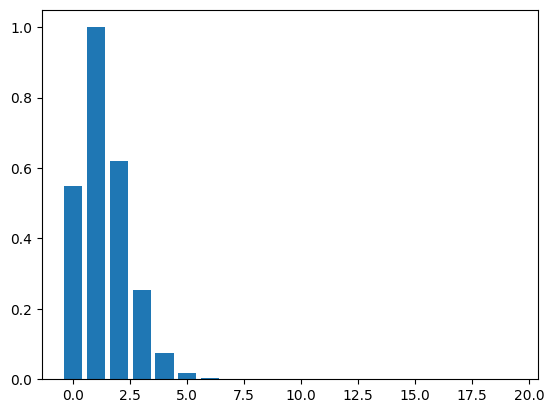

In [67]:
plt_bar(2)

In [68]:
import torch.nn as nn 

# first model
encoder = nn.Sequential(nn.Linear(20, 30), 
                        nn.ReLU(),
                        nn.Linear(30, 40))

decoder = nn.Sequential(nn.Linear(40, 30),
                        nn.ReLU(),
                        nn.Linear(30, 20),                        
                        nn.Sigmoid())

autoenc = nn.Sequential(encoder, decoder)


In [69]:
import torch 

torch_small_df = torch.from_numpy(small_df)
torch_small_df = torch_small_df.to(torch.float32)

In [70]:
from torch.utils.data import Dataset, DataLoader

class HistDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        return self.df[idx]

In [71]:
torch_small_df = HistDataset(torch_small_df)
dataloader = DataLoader(torch_small_df, batch_size=16, shuffle=False)

In [72]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(params=autoenc.parameters(), lr=0.01)

In [73]:
# first model training loop
losses = []
n_epochs = 1000
autoenc.train()

for e in range(n_epochs):
    for pt in dataloader:
        recreated = autoenc(pt)
        loss = criterion(recreated, pt)
        loss.backward()
        optimizer.step()
        losses.append(loss.detach().numpy())

    print(f'Epoch: {e} | Loss: {loss.detach().numpy()}')    

Epoch: 0 | Loss: 0.013829592615365982
Epoch: 1 | Loss: 0.02046375721693039
Epoch: 2 | Loss: 0.02115054614841938
Epoch: 3 | Loss: 0.02115054614841938
Epoch: 4 | Loss: 0.02115054614841938
Epoch: 5 | Loss: 0.02115054614841938
Epoch: 6 | Loss: 0.02115054614841938
Epoch: 7 | Loss: 0.02115054614841938
Epoch: 8 | Loss: 0.02115054614841938
Epoch: 9 | Loss: 0.02115054614841938
Epoch: 10 | Loss: 0.02115054614841938
Epoch: 11 | Loss: 0.02115054614841938
Epoch: 12 | Loss: 0.02115054614841938
Epoch: 13 | Loss: 0.02115054614841938
Epoch: 14 | Loss: 0.02115054614841938
Epoch: 15 | Loss: 0.02115054614841938
Epoch: 16 | Loss: 0.02115054614841938
Epoch: 17 | Loss: 0.02115054614841938
Epoch: 18 | Loss: 0.02115054614841938
Epoch: 19 | Loss: 0.02115054614841938
Epoch: 20 | Loss: 0.02115054614841938
Epoch: 21 | Loss: 0.02115054614841938
Epoch: 22 | Loss: 0.02115054614841938
Epoch: 23 | Loss: 0.02115054614841938
Epoch: 24 | Loss: 0.02115054614841938
Epoch: 25 | Loss: 0.02115054614841938
Epoch: 26 | Loss: 0.0

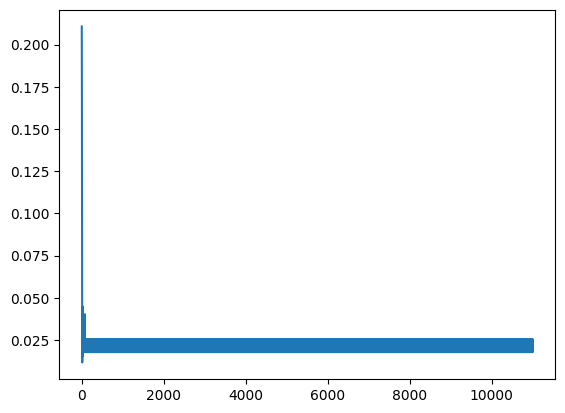

In [74]:
plt.plot(range(len(losses)), losses)

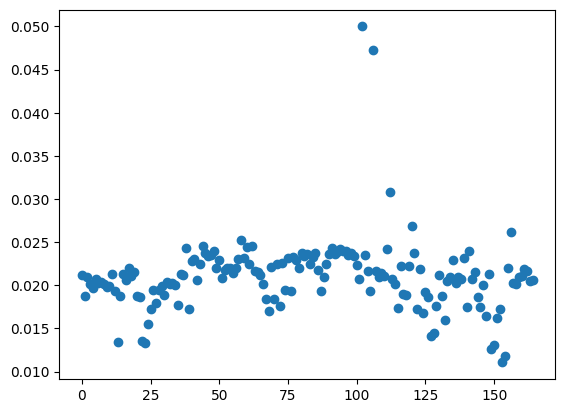

In [75]:
autoenc.eval()
score = []
for pt in torch_small_df:
    loss = criterion(autoenc(pt), pt)
    score.append(loss.detach().numpy())

plt.scatter(range(len(score)), score)
plt.show()

In [76]:
top_scores = sorted(score)[-3:]
for s in top_scores:
    print(score.index(s))

112
106
102


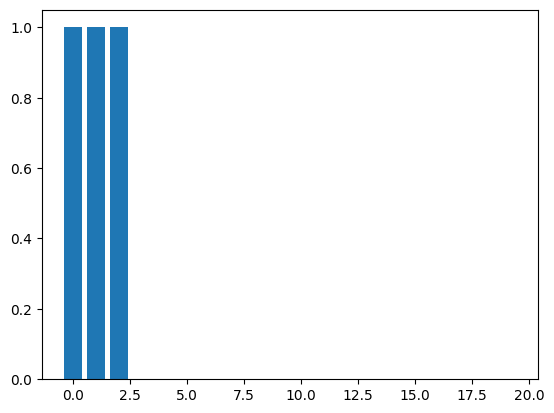

In [77]:
pred = autoenc(torch_small_df[106])
pred = pred.detach().numpy()
plt.bar(range(len(pred)), pred)
plt.show()